# XG Boost Algorithm -> Model

In [1]:
!pip install xgboost


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 842.2 kB/s eta 0:00:58
    --------------------------------------- 0.8/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.3/48.9 MB 1.5 MB/s eta 0:00:33
   - -------------------------------------- 2.1/48.9 MB 2.0 MB/s eta 0:00:24
   -- ------------------------------------- 2.6/48.9 MB 2.0 MB/s eta 0:00:24
   -- ------------------------------------- 3.4/48.9 MB 2.2 MB/s eta 0:00:21
   --- ------------------------------------ 4.2/48.9 MB 2.4 MB/s eta 0:00:19
   ---- ----------------------------------- 5.0/48.9 MB 2.5 MB/s eta 0:00:18
   ---- ----------------------------------- 5.8/48.9 MB 2.7 MB/s eta 0:00:16
   ----- ----------------

In [9]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# print(xgb.__version__)

encoder = LabelEncoder()
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    eval_metric="mlogloss",
    random_state=42,
)

db = pd.read_csv('standardized_crops.csv')

X = db.drop("label", axis=1)
y = db['label']


y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


model.fit(X_train,y_train)

predictions = model.predict(X_test)

predicted_crops = encoder.inverse_transform(predictions)

print(predicted_crops[:10])

['Potato (Aloo)' 'Sweet Potato (Shakarkandi)' 'Rapeseed (Sarson)'
 'Sunflower (Surajmukhi)' 'Onion (Pyaaz)' 'Pigeon Peas (Tur/Arhar)'
 'Maize (Corn)' 'Sunflower (Surajmukhi)' 'Garlic (Lehsun)' 'Onion (Pyaaz)']


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,predictions)
print("Training accuracy : ",model.score(X_train,y_train))
print("Testing accuracy : ",model.score(X_test,y_test))
print("Accuracy : ", accuracy)

Training accuracy :  1.0
Testing accuracy :  0.996969696969697
Accuracy :  0.996969696969697


In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions,
        target_names=encoder.classes_,
        zero_division=0
    )
)

                              precision    recall  f1-score   support

                       Apple       1.00      1.00      1.00        20
                      Banana       1.00      1.00      1.00        20
                Barley (Jau)       1.00      1.00      1.00        38
       Bitter Gourd (Karela)       1.00      1.00      1.00         2
           Black Gram (Urad)       1.00      1.00      1.00        20
   Black Pepper (Kali Mirch)       1.00      1.00      1.00        14
        Bottle Gourd (Lauki)       1.00      1.00      1.00         2
  Brinjal (Eggplant/Baingan)       1.00      1.00      1.00         9
         Cabbage (Band Gobi)       1.00      1.00      1.00         4
          Cardamom (Elaichi)       1.00      1.00      1.00         8
    Cauliflower (Phool Gobi)       1.00      1.00      1.00         4
             Chickpea (Gram)       1.00      1.00      1.00        20
           Coconut (Nariyal)       1.00      0.90      0.95        20
                   

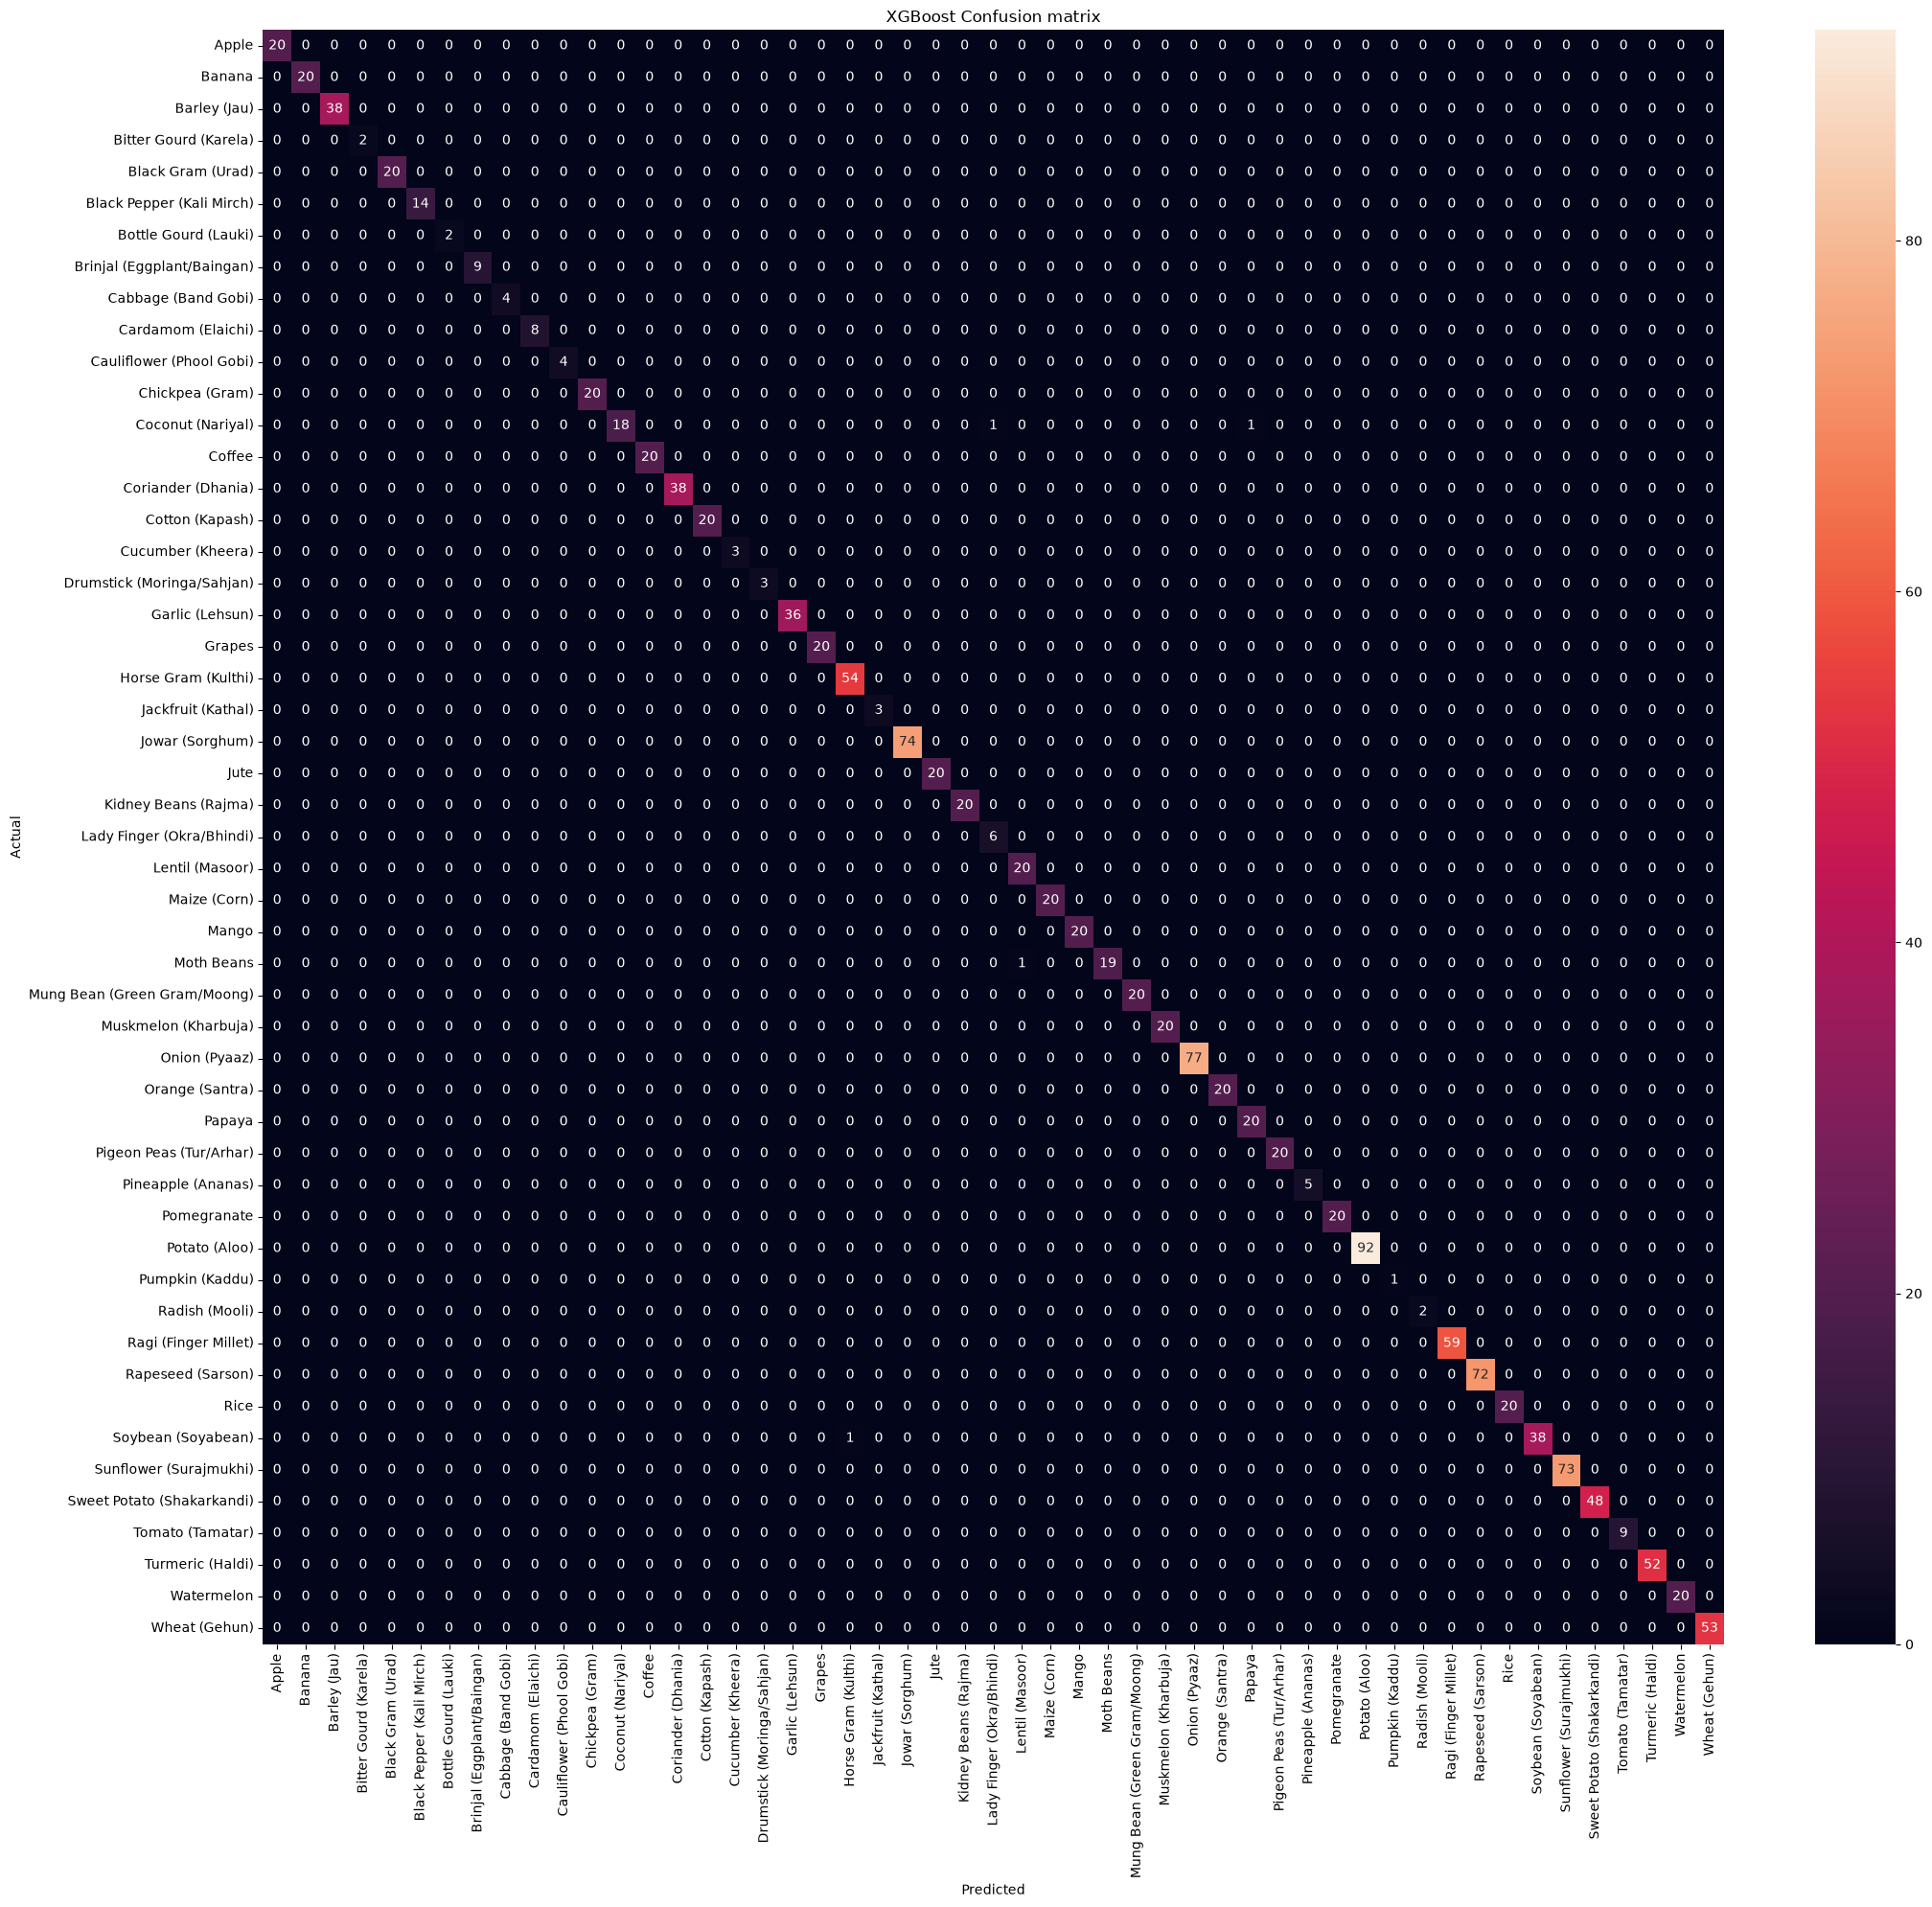

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,predictions
)

plt.figure(figsize=(22,20))

sns.heatmap(
    cm,
    annot=True,
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion matrix")


plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [15]:

new_data = pd.DataFrame([{
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 20.8,
    "humidity": 82.0,
    "ph": 6.5,
    "rainfall": 202.9
}])

prediction = model.predict(new_data)

crop = encoder.inverse_transform(prediction)

print("Predicted crop:", crop[0])

Predicted crop: Rice
